# Analyzing Tune Experiment Results
The content in this notebook uses the [Analyzing Tune Experiment Results](https://docs.ray.io/en/latest/tune/examples/tune_analyze_results.html?highlight=results%20json#analyzing-tune-experiment-results) section of the Ray docs. See the link for more details.

In [1]:
import os

import pandas as pd

import ray
from ray import tune

In [2]:
os.environ["PATH"] = ":".join([os.environ["PATH"], f"{os.environ['HOME']}/simharness2"])

In [3]:
EXPERIMENT_DIR = "/nfs/lslab2/fireline/simharness/experiments/2023-11-13_02-09-07/DQN"
TRIAL_DIR = "/nfs/lslab2/fireline/simharness/experiments/2023-11-13_02-09-07/DQN/DQN_simharness2.environments.reactive_bench_sarl.ReactiveHarness_b015d_00000_0_2023-11-13_02-09-35"

In [4]:
EXPERIMENT_DIR = "/nfs/lslab2/fireline/simharness/experiments/2023-11-17_04-36-32/DQN"
TRIAL_DIR = "/nfs/lslab2/fireline/simharness/experiments/2023-11-17_04-36-32/DQN/DQN_simharness2.environments.reactive_bench_sarl.ReactiveHarness_ebceb_00000_0_2023-11-17_04-36-51"

## Experiment-level Analysis: Working with `ResultGrid`

In [5]:
print(f"Loading results from {EXPERIMENT_DIR}...")
restored_tuner = tune.Tuner.restore(EXPERIMENT_DIR, trainable="DQN")

result_grid = restored_tuner.get_results()

Loading results from /nfs/lslab2/fireline/simharness/experiments/2023-11-17_04-36-32/DQN...


2023-11-19 05:21:30,025	INFO experiment_analysis.py:972 -- No trial data passed in during `ExperimentAnalysis` initialization -- you are most likely loading the experiment after it has completed.
Loading trial data from the experiment checkpoint file. This may result in loading some stale information, since checkpointing is periodic.
/home/dgandikota/.conda/envs/sh2/lib/python3.9/site-packages/pydantic/_internal/_config.py:317: UserWarning: Valid config keys have changed in V2:
* 'allow_mutation' has been removed
  warnings.warn(message, UserWarning)
2023-11-19 05:21:33,935	WARNING deprecation.py:50 -- DeprecationWarning: `DirectStepOptimizer` has been deprecated. This will raise an error in the future!


In [6]:
results_df = result_grid.get_dataframe()
results_df

,episode_reward_max,episode_reward_min,episode_reward_mean,episode_len_mean,episodes_this_iter,num_faulty_episodes,num_healthy_workers,num_in_flight_async_reqs,num_remote_worker_restarts,num_agent_steps_sampled,...,config/evaluation_config/env_config/interactions,config/evaluation_config/env_config/is_evaluation_env,config/evaluation_config/env_config/movements,config/evaluation_config/env_config/normalized_attributes,config/evaluation_config/env_config/randomize_initial_agent_pos,config/evaluation_config/env_config/reward_cls_partial,config/evaluation_config/env_config/sim,config/tf_session_args/device_count/CPU,config/tf_session_args/gpu_options/allow_growth,logdir
0,1.069734,0.019915,0.186154,500.72,8,0,8,0,0,12640624,...,[fireline],True,"[up, down, left, right]",[],False,functools.partial(<class 'simharness2.rewards....,<simfire.sim.simulation.FireSimulation object ...,1,True,/nfs/lslab2/fireline/simharness/experiments/20...


## Trial-level Analysis: Working with an individual `Result`

In [7]:
from ray.air import Result

# Get the best result
best_result: Result = result_grid.get_best_result()

In [8]:
# best_result

In [9]:
# best_result.config

In [10]:
best_result.checkpoint

Checkpoint(local_path=/nfs/lslab2/fireline/simharness/experiments/2023-11-17_04-36-32/DQN/DQN_simharness2.environments.reactive_bench_sarl.ReactiveHarness_ebceb_00000_0_2023-11-17_04-36-51/checkpoint_003000)

## Metric Extraction: Access the entire history of reported metrics from a `Result` as a pandas DataFrame

In [11]:
trial_df = best_result.metrics_dataframe
trial_df

,episode_reward_max,episode_reward_min,episode_reward_mean,episode_len_mean,episodes_this_iter,num_faulty_episodes,num_healthy_workers,num_in_flight_async_reqs,num_remote_worker_restarts,num_agent_steps_sampled,...,sampler_results/hist_stats/episode_reward,sampler_results/hist_stats/episode_lengths,sampler_results/sampler_perf/mean_raw_obs_processing_ms,sampler_results/sampler_perf/mean_inference_ms,sampler_results/sampler_perf/mean_action_processing_ms,sampler_results/sampler_perf/mean_env_wait_ms,sampler_results/sampler_perf/mean_env_render_ms,sampler_results/connector_metrics/ObsPreprocessorConnector_ms,sampler_results/connector_metrics/StateBufferConnector_ms,sampler_results/connector_metrics/ViewRequirementAgentConnector_ms
0,0.074937,0.043344,0.057327,530.000,8,0,8,0,0,4240,...,"[0.052017409021895514, 0.052913914909178295, 0...","[529, 529, 529, 529, 537, 529, 529, 529]",17.432607,10.279257,0.294464,51.024039,0.0,0.017762,0.009882,0.354159
1,0.249836,0.043344,0.087692,539.750,8,0,8,0,0,8636,...,"[0.052017409021895514, 0.052913914909178295, 0...","[529, 529, 529, 529, 537, 529, 529, 529, 541, ...",17.272576,10.212623,0.291942,41.779680,0.0,0.018010,0.009957,0.359705
2,0.249836,0.043344,0.081778,529.500,8,0,8,0,0,12708,...,"[0.052017409021895514, 0.052913914909178295, 0...","[529, 529, 529, 529, 537, 529, 529, 529, 541, ...",17.385125,10.284192,0.292112,37.063596,0.0,0.018266,0.010201,0.365073
3,0.249836,0.043344,0.082567,535.375,8,0,8,0,0,17132,...,"[0.052017409021895514, 0.052913914909178295, 0...","[529, 529, 529, 529, 537, 529, 529, 529, 541, ...",18.022177,10.337604,0.291574,33.902520,0.0,0.020180,0.010390,0.370633
4,0.249836,0.038490,0.075769,530.100,8,0,8,0,0,21204,...,"[0.052017409021895514, 0.052913914909178295, 0...","[529, 529, 529, 529, 537, 529, 529, 529, 541, ...",18.370045,10.394875,0.291647,32.115751,0.0,0.019922,0.010432,0.373095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3026,1.069734,0.015320,0.168998,543.920,8,0,8,0,0,12625008,...,"[0.051682989172196575, 0.11266924361533376, 0....","[761, 761, 761, 761, 617, 617, 617, 617, 617, ...",23.377535,9.868776,0.280842,21.024336,0.0,0.022688,0.010386,0.377350
3027,1.069734,0.023928,0.179012,537.200,8,0,8,0,0,12629848,...,"[0.023927769864113407, 0.036264545437486945, 0...","[617, 617, 617, 617, 677, 677, 677, 677, 677, ...",23.377168,9.868822,0.280843,21.023887,0.0,0.023024,0.010405,0.377105
3028,1.069734,0.027907,0.179304,518.800,8,0,8,0,0,12633184,...,"[0.03313847494581312, 0.04126152952098124, 0.0...","[677, 677, 677, 677, 497, 497, 497, 497, 497, ...",23.377153,9.868866,0.280844,21.023604,0.0,0.023399,0.010405,0.377548
3029,1.069734,0.027907,0.187841,512.880,8,0,8,0,0,12637288,...,"[0.032812278621614156, 0.055164726521630146, 0...","[497, 497, 497, 497, 641, 641, 641, 641, 641, ...",23.377173,9.868905,0.280845,21.023494,0.0,0.023802,0.010371,0.376678


### Extract Metrics for NeurIPS content

In [12]:
METRIC_COLUMNS = [
    "episodes_total",
    "training_iteration",
    "episode_reward_mean", 
    "custom_metrics/burn_rate_reduction_mean", 
    "custom_metrics/timesteps_saved_mean", 
    "custom_metrics/area_saved_mean"
]

In [13]:
metrics_df = trial_df[METRIC_COLUMNS].set_index("training_iteration")

In [14]:
# Truncate metrics to omit episodes AFTER 13496 (after the forgetting begins)
#metrics_df = metrics_df[metrics_df["episodes_total"] <= 13500]
metrics_df = metrics_df[metrics_df["episodes_total"] <= 25000]
metrics_df

,episodes_total,episode_reward_mean,custom_metrics/burn_rate_reduction_mean,custom_metrics/timesteps_saved_mean,custom_metrics/area_saved_mean
training_iteration,,,,,
1,8,0.057327,0.328648,-1.000000,17.2500
2,16,0.087692,0.352038,-4.750000,29.5625
3,24,0.081778,0.316470,-3.166667,20.2500
4,32,0.082567,0.310646,-2.375000,20.6250
5,40,0.075769,0.306916,-1.900000,18.9750
...,...,...,...,...,...
3027,24720,0.168998,0.868445,4.920000,266.7000
3028,24728,0.179012,0.872235,4.920000,264.0500
3029,24736,0.179304,0.877843,4.920000,263.6300


In [15]:
# NOTE: Must install `hvplot` and `holoviews` for the below line to work. 
# I was just experimenting with the different plotting backends...
#pd.options.plotting.backend = 'holoviews'


### Final Graphs


<Axes: title={'center': 'Episode Reward Mean over Training'}, xlabel='Num Trained Episodes'>

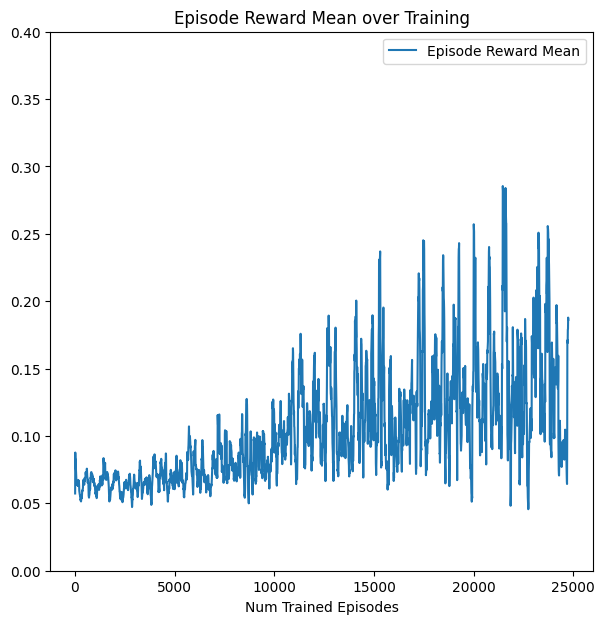

In [36]:
metrics_df.rename(columns={"episode_reward_mean": "Episode Reward Mean"}).plot(y="Episode Reward Mean", x='episodes_total', ylim = (0,0.4), xlabel = 'Num Trained Episodes', title = "Episode Reward Mean over Training", figsize = (7,7))

<Axes: title={'center': 'Mean Timesteps Saved by Agent over Training'}, xlabel='Num Trained Episodes', ylabel='Time (timesteps) Reduction Mean in Simulation \n After Agent Mitigations Introduced'>

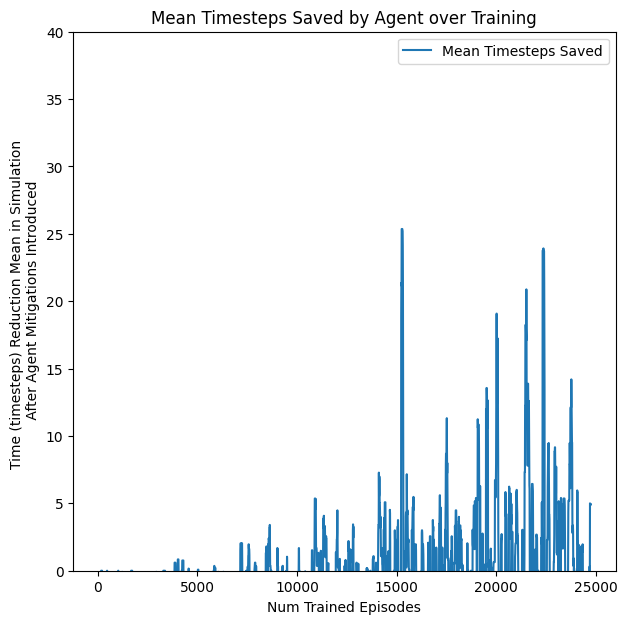

In [35]:
metrics_df.rename(columns={"custom_metrics/timesteps_saved_mean": "Mean Timesteps Saved"}).plot(y="Mean Timesteps Saved", x='episodes_total', ylim = (0,40), xlabel = 'Num Trained Episodes', title = "Mean Timesteps Saved by Agent over Training", ylabel = 'Time (timesteps) Reduction Mean in Simulation \n After Agent Mitigations Introduced', figsize = (7,7))

In [18]:
metrics_df["custom_metrics/burn_rate_reduction_mean"] = metrics_df["custom_metrics/burn_rate_reduction_mean"] * 100.0


<Axes: title={'center': 'Mean Burn Rate Reduction by Agent over Training'}, xlabel='Num Trained Episodes', ylabel='Burn Rate (%) Reduction Mean \n After Agent Mitigations Introduced'>

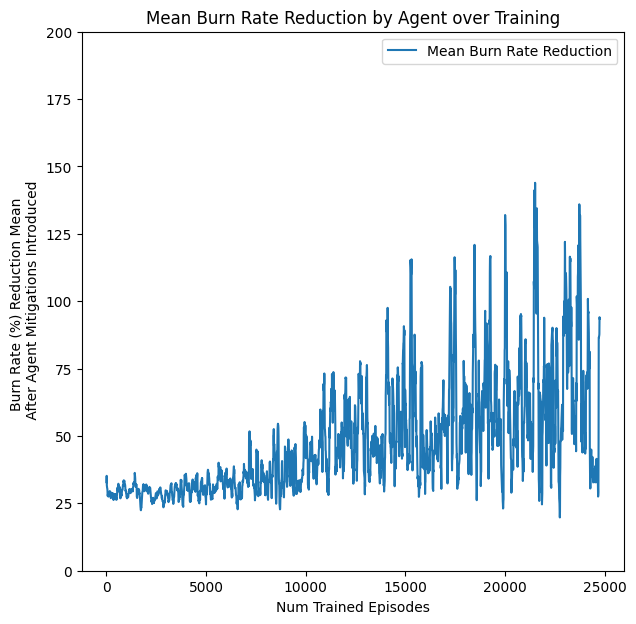

In [34]:

metrics_df.rename(columns={"custom_metrics/burn_rate_reduction_mean": "Mean Burn Rate Reduction"}).plot(y="Mean Burn Rate Reduction", x='episodes_total', ylim = (0,200), xlabel = 'Num Trained Episodes', title = "Mean Burn Rate Reduction by Agent over Training", ylabel = 'Burn Rate (%) Reduction Mean \n After Agent Mitigations Introduced', figsize = (7,7))

<Axes: title={'center': 'Mean Area Saved by Agent over Training'}, xlabel='Num Trained Episodes', ylabel='Area (Grid Cells) Remaining Unburned Mean \n After Agent Mitigations Introduced'>

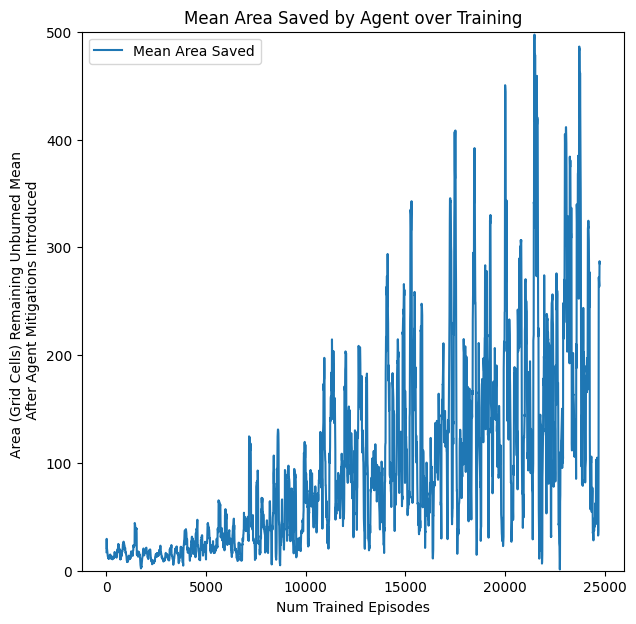

In [33]:
metrics_df.rename(columns={"custom_metrics/area_saved_mean": "Mean Area Saved"}).plot(y="Mean Area Saved", x='episodes_total', ylim = (0,500), xlabel = 'Num Trained Episodes', ylabel = 'Area (Grid Cells) Remaining Unburned Mean \n After Agent Mitigations Introduced', figsize = (7,7), title = "Mean Area Saved by Agent over Training")

### Add Smoothing

In [21]:
from scipy.interpolate import interp1d
import numpy as np

In [22]:
metrics_df2 = metrics_df.copy()
#metrics_df2["custom_metrics/burn_rate_reduction_mean"] = metrics_df2["custom_metrics/burn_rate_reduction_mean"] * 100.0
#metrics_df2 =metrics_df2.interpolate(method='cubic')

In [23]:

#ax = metrics_df2.plot(alpha = .5)

<Axes: title={'center': 'Episode Reward Mean over Training'}, xlabel='Num Trained Episodes', ylabel='Episode Reward Score Mean'>

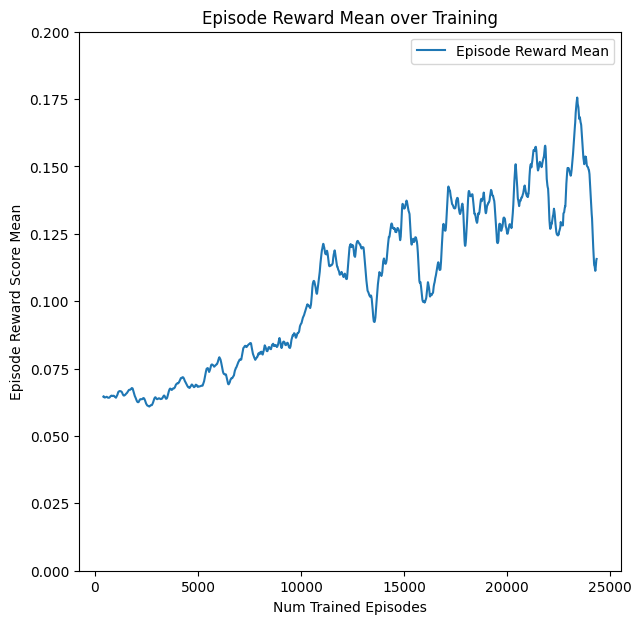

In [29]:
window = 100
rolling = metrics_df2.rolling(window).mean()
rolling.rename(columns={"episode_reward_mean": "Episode Reward Mean"}).plot(y="Episode Reward Mean", x='episodes_total', ylim = (0,0.2), xlabel = 'Num Trained Episodes', title = "Episode Reward Mean over Training", figsize = (7,7), ylabel = 'Episode Reward Score Mean')

<Axes: title={'center': 'Mean Timesteps Saved by Agent over Training'}, xlabel='Num Trained Episodes', ylabel='Time (timesteps) Reduction Mean in Simulation \n After Agent Mitigations Introduced'>

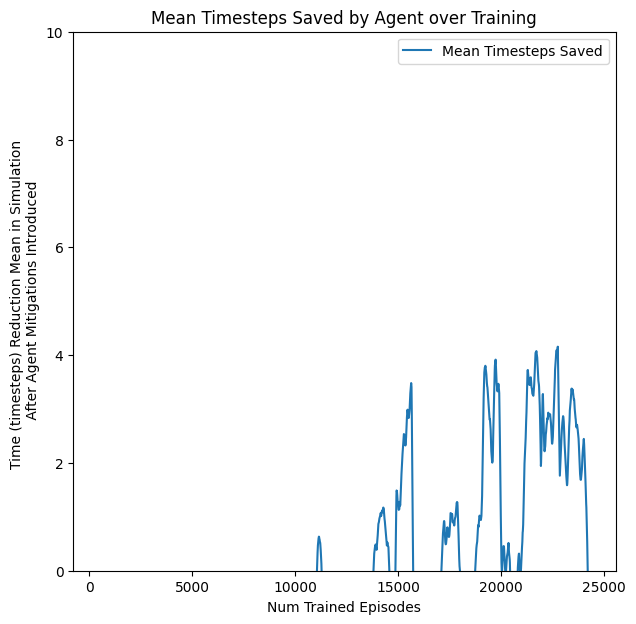

In [30]:
window = 100
rolling = metrics_df2.rolling(window).mean()
rolling.rename(columns={"custom_metrics/timesteps_saved_mean": "Mean Timesteps Saved"}).plot(y="Mean Timesteps Saved", x='episodes_total', ylim = (0,10), xlabel = 'Num Trained Episodes', title = "Mean Timesteps Saved by Agent over Training", ylabel = 'Time (timesteps) Reduction Mean in Simulation \n After Agent Mitigations Introduced', figsize = (7,7))

<Axes: title={'center': 'Mean Burn Rate Reduction by Agent over Training'}, xlabel='Num Trained Episodes', ylabel='Burn Rate (%) Reduction Mean \n After Agent Mitigations Introduced'>

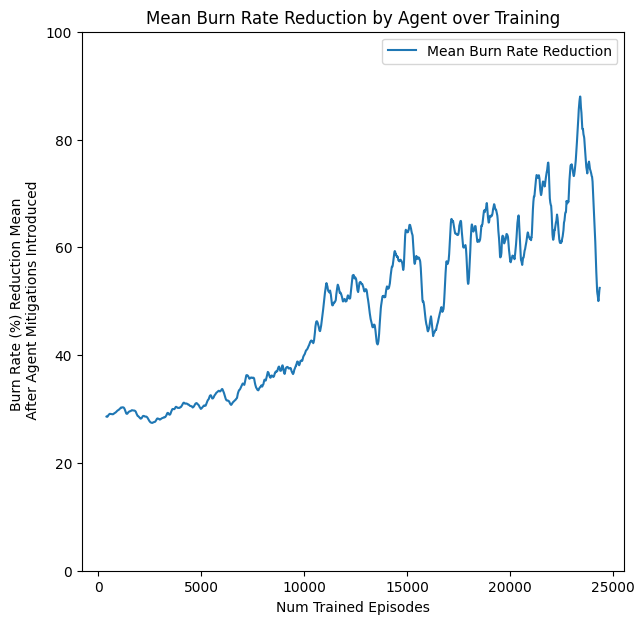

In [32]:
window = 100
rolling = metrics_df2.rolling(window).mean()
rolling.rename(columns={"custom_metrics/burn_rate_reduction_mean": "Mean Burn Rate Reduction"}).plot(y="Mean Burn Rate Reduction", x='episodes_total', ylim = (0,100), xlabel = 'Num Trained Episodes', title = "Mean Burn Rate Reduction by Agent over Training", ylabel = 'Burn Rate (%) Reduction Mean \n After Agent Mitigations Introduced', figsize = (7,7))

<Axes: title={'center': 'Mean Area Saved by Agent over Training'}, xlabel='Num Trained Episodes', ylabel='Area (Grid Cells) Remaining Unburned Mean \n After Agent Mitigations Introduced'>

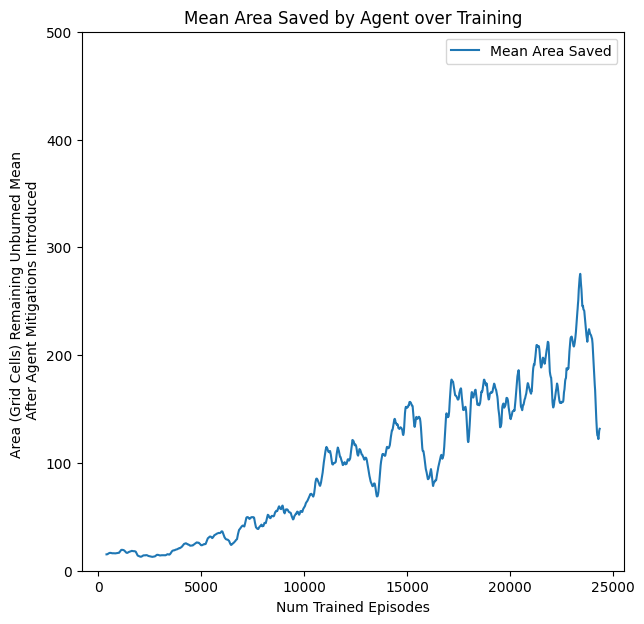

In [31]:
window = 100
rolling = metrics_df2.rolling(window).mean()
rolling.rename(columns={"custom_metrics/area_saved_mean": "Mean Area Saved"}).plot(y="Mean Area Saved", x='episodes_total', ylim = (0,500), xlabel = 'Num Trained Episodes', ylabel = 'Area (Grid Cells) Remaining Unburned Mean \n After Agent Mitigations Introduced', figsize = (7,7), title = "Mean Area Saved by Agent over Training")